# Lección 5 — Redes de Neuronas Profundas y PyTorch


**Repositorio:** `deep-learning-complete-guide`
**Objetivo:** entender las redes profundas, composición de capas, profundidad, anchura, número de parámetros, inicialización, normalización y regularización. Enterder el famoso framework de PyTorch: tensores, autograd, `Dataset`, `DataLoader`, `nn.Module`, optimizadores y entrenamiento completo de una red.

## Índice

1. [Configuración inicial](#1-configuración-inicial)  
2. [De una red no profunda a una red profunda](#2-de-una-red-no-profunda-a-una-red-profunda)  
3. [Notación general y número de parámetros](#3-notación-general-y-número-de-parámetros)  
4. [Redes profundas con PyTorch](#4-redes-profundas-con-pytorch)  
5. [Backpropagation en redes profundas](#5-backpropagation-en-redes-profundas)  
6. [Inicialización de parámetros](#6-inicialización-de-parámetros)  
7. [Normalización y Batch Normalization](#7-normalización-y-batch-normalization)  
8. [Regularización en redes profundas](#8-regularización-en-redes-profundas)  
9. [Entrenamiento completo con PyTorch](#9-entrenamiento-completo-con-pytorch)  
10. [Ejercicios tipo examen resueltos](#10-ejercicios-tipo-examen-resueltos)  
11. [Resumen final](#11-resumen-final)

## 1. Configuración inicial

Usaremos `torch` para las redes neuronales, `numpy` para cálculos auxiliares y `matplotlib` para representar funciones y curvas de entrenamiento.

<div style="background:rgba(92,184,92,0.13);border-left:5px solid #3c763d;padding:14px;border-radius:6px;color:inherit">

### Reproducibilidad

En Deep Learning no siempre se obtiene exactamente el mismo resultado si cambian la GPU, las librerías o el sistema, pero fijar semillas ayuda a que los experimentos sean mucho más estables.

</div>

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

---

## 2. De una red no profunda a una red profunda

En el tema anterior vimos redes con una única capa oculta. Una red de ese tipo ya es capaz de aproximar muchas funciones, pero las **redes profundas** añaden una idea fundamental:

> En lugar de aprender una única transformación grande, aprenden una **composición de transformaciones**.

Una red profunda aplica capas de forma secuencial:

$$
x \rightarrow h_1 \rightarrow h_2 \rightarrow \dots \rightarrow h_K \rightarrow y
$$

Cada capa transforma la representación anterior en otra representación más útil para la tarea.

<div style="background:rgba(240,173,78,0.15);border-left:5px solid #f0ad4e;padding:14px;border-radius:6px;color:inherit">

### Intuición importante

Una red profunda no solo clasifica o aproxima una función. También **aprende características intermedias**.  
Las primeras capas producen representaciones simples y las capas posteriores combinan esas representaciones para obtener patrones más complejos.

</div>

### 2.1 Red no profunda

Una red con una sola capa oculta puede escribirse como:

$$
h = a(\Omega_0 x + \beta_0)
$$

$$
y = \Omega_1 h + \beta_1
$$

donde:

- $x$ es la entrada;
- $\Omega_0$ y $\beta_0$ son pesos y sesgos de la primera capa lineal;
- $a(\cdot)$ es la función de activación;
- $h$ son las activaciones ocultas;
- $\Omega_1$ y $\beta_1$ son pesos y sesgos de salida.

En PyTorch, esta estructura se implementa con `nn.Linear`, una activación y otra `nn.Linear`.

In [2]:
class ShallowNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)


shallow_model = ShallowNet(input_dim=2, hidden_dim=8, output_dim=1)
shallow_model

ShallowNet(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)

### 2.2 Red profunda

Una red profunda tiene más de una capa oculta:

$$
h_1 = a(\Omega_0x + \beta_0)
$$

$$
h_2 = a(\Omega_1h_1 + \beta_1)
$$

$$
\vdots
$$

$$
h_K = a(\Omega_{K-1}h_{K-1} + \beta_{K-1})
$$

$$
y = \Omega_Kh_K + \beta_K
$$

La diferencia principal no está solo en tener más parámetros, sino en que cada capa aprende una transformación sobre la representación anterior.

In [3]:
class DeepNet(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=1, n_hidden_layers=4):
        super().__init__()

        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        for _ in range(n_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(hidden_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


deep_model = DeepNet(input_dim=2, hidden_dim=16, output_dim=1, n_hidden_layers=4)
deep_model

DeepNet(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

### 2.3 Composición y regiones lineales

Con activaciones ReLU, una red genera funciones **lineales a trozos**.  
Cada ReLU introduce cambios de comportamiento según si su preactivación es positiva o negativa.

En una red no profunda con entrada 1D y $D$ unidades ocultas, el número máximo de regiones lineales es aproximadamente:

$$
R = D + 1
$$

En una red profunda con $K$ capas ocultas y $D$ unidades por capa, una idea simplificada para entrada 1D es:

$$
R \approx (D+1)^K
$$

Por eso, aumentar la profundidad puede producir funciones mucho más expresivas por parámetro.

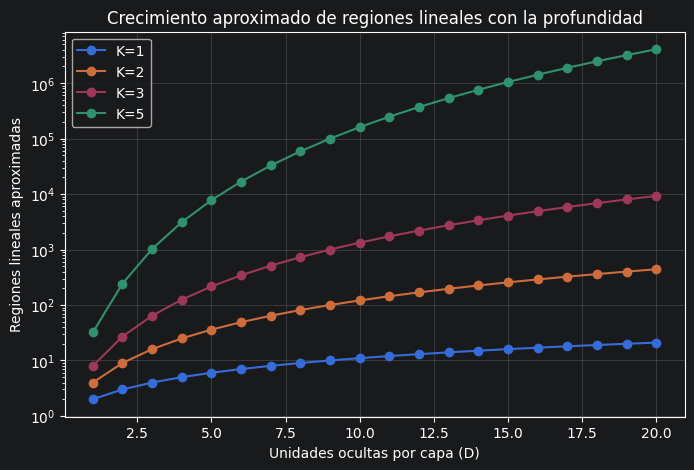

In [4]:
def max_regions_shallow(D):
    return D + 1

def approx_regions_deep(D, K):
    return (D + 1) ** K

D_values = np.arange(1, 21)
K_values = [1, 2, 3, 5]

plt.figure(figsize=(8, 5))
for K in K_values:
    regions = [approx_regions_deep(D, K) for D in D_values]
    plt.plot(D_values, regions, marker="o", label=f"K={K}")

plt.yscale("log")
plt.xlabel("Unidades ocultas por capa (D)")
plt.ylabel("Regiones lineales aproximadas")
plt.title("Crecimiento aproximado de regiones lineales con la profundidad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Idea de examen

Las redes profundas pueden representar funciones complejas de forma más eficiente que redes no profundas.  
No significa que siempre sean mejores, pero sí que la **composición de capas** permite reutilizar representaciones y crear muchas regiones lineales con menos parámetros que una red plana equivalente.

</div>

---

## 3. Notación general y número de parámetros

Una red completamente conectada con:

- $D_i$ entradas;
- $D_o$ salidas;
- $K$ capas ocultas;
- $D$ unidades ocultas en cada capa;

tiene esta estructura:

$$
x \in \mathbb{R}^{D_i}
$$

Primera capa oculta:

$$
h_1 = a(\Omega_0x + \beta_0)
$$

Capas ocultas intermedias:

$$
h_k = a(\Omega_{k-1}h_{k-1} + \beta_{k-1}), \quad k=2,\dots,K
$$

Capa de salida:

$$
y = \Omega_Kh_K + \beta_K
$$

### 3.1 Fórmula del número de parámetros

Cada capa `Linear(in_features, out_features)` tiene:

$$
\text{parámetros} = \text{in\_features} \cdot \text{out\_features} + \text{out\_features}
$$

porque aprende:

- una matriz de pesos;
- un sesgo por cada neurona de salida.

Para la red profunda anterior:

$$
P =
\underbrace{D(D_i + 1)}_{\text{entrada a primera capa oculta}}
+
\underbrace{(K-1)D(D+1)}_{\text{capas ocultas intermedias}}
+
\underbrace{D_o(D+1)}_{\text{última capa a salida}}
$$

<div style="background:rgba(92,184,92,0.13);border-left:5px solid #3c763d;padding:14px;border-radius:6px;color:inherit">

### Lectura rápida

- Primera capa: conecta $D_i$ entradas con $D$ neuronas.
- Capas ocultas intermedias: hay $K-1$ conexiones de $D$ a $D$.
- Capa final: conecta $D$ neuronas ocultas con $D_o$ salidas.

</div>

In [5]:
def count_parameters_formula(Di, Do, K, D):
    first_hidden = D * Di + D
    hidden_to_hidden = (K - 1) * (D * D + D)
    output_layer = Do * D + Do
    total = first_hidden + hidden_to_hidden + output_layer
    return {
        "first_hidden": first_hidden,
        "hidden_to_hidden": hidden_to_hidden,
        "output_layer": output_layer,
        "total": total
    }


count_parameters_formula(Di=1, Do=2, K=8, D=10)

{'first_hidden': 20, 'hidden_to_hidden': 770, 'output_layer': 22, 'total': 812}

In [6]:
def build_fully_connected_deep_net(Di, Do, K, D, activation=nn.ReLU):
    layers = []

    # Primera capa oculta
    layers.append(nn.Linear(Di, D))
    layers.append(activation())

    # Capas ocultas intermedias
    for _ in range(K - 1):
        layers.append(nn.Linear(D, D))
        layers.append(activation())

    # Capa de salida
    layers.append(nn.Linear(D, Do))

    return nn.Sequential(*layers)


net_exercise = build_fully_connected_deep_net(Di=1, Do=2, K=8, D=10)

def count_parameters_torch(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(net_exercise)
print("Parámetros según PyTorch:", count_parameters_torch(net_exercise))

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=10, bias=True)
  (5): ReLU()
  (6): Linear(in_features=10, out_features=10, bias=True)
  (7): ReLU()
  (8): Linear(in_features=10, out_features=10, bias=True)
  (9): ReLU()
  (10): Linear(in_features=10, out_features=10, bias=True)
  (11): ReLU()
  (12): Linear(in_features=10, out_features=10, bias=True)
  (13): ReLU()
  (14): Linear(in_features=10, out_features=10, bias=True)
  (15): ReLU()
  (16): Linear(in_features=10, out_features=2, bias=True)
)
Parámetros según PyTorch: 812


---

## 4. Redes profundas con PyTorch

PyTorch se basa en varios conceptos importantes:

| Concepto | Uso |
|---|---|
| `torch.Tensor` | Estructura básica de datos |
| `requires_grad=True` | Permite guardar operaciones para calcular gradientes |
| `torch.autograd` | Motor de diferenciación automática |
| `nn.Module` | Clase base para modelos |
| `nn.Linear` | Capa completamente conectada |
| `DataLoader` | Carga datos por mini-batches |
| `torch.optim` | Optimización de parámetros |

### 4.1 Tensores

Un tensor es una matriz multidimensional. En PyTorch se parece a un array de NumPy, pero puede vivir en CPU o GPU y puede participar en grafos de cómputo.

In [7]:
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print("Tensor:")
print(x)
print("Shape:", x.shape)
print("Tipo:", x.dtype)
print("Dispositivo:", x.device)

Tensor:
tensor([[1., 2.],
        [3., 4.]])
Shape: torch.Size([2, 2])
Tipo: torch.float32
Dispositivo: cpu


### 4.2 Operaciones y dimensiones

En Deep Learning, muchos errores vienen de dimensiones incompatibles.  
Conviene comprobar siempre las formas (`shape`) de tensores, pesos y salidas.

In [8]:
batch_size = 5
input_dim = 3
output_dim = 2

x_batch = torch.randn(batch_size, input_dim)
linear = nn.Linear(input_dim, output_dim)

y_batch = linear(x_batch)

print("x_batch.shape:", x_batch.shape)
print("linear.weight.shape:", linear.weight.shape)
print("linear.bias.shape:", linear.bias.shape)
print("y_batch.shape:", y_batch.shape)

x_batch.shape: torch.Size([5, 3])
linear.weight.shape: torch.Size([2, 3])
linear.bias.shape: torch.Size([2])
y_batch.shape: torch.Size([5, 2])


### 4.3 Autograd

`autograd` calcula automáticamente derivadas siempre que las operaciones se hagan con tensores de PyTorch y los tensores relevantes tengan `requires_grad=True`.

Ejemplo:

$$
f(a,b,c) = (a + 2b)c
$$

Las derivadas analíticas son:

$$
\frac{\partial f}{\partial a}=c
$$

$$
\frac{\partial f}{\partial b}=2c
$$

$$
\frac{\partial f}{\partial c}=a+2b
$$

In [9]:
a = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
c = torch.tensor(-2.0, requires_grad=True)

f = (a + 2 * b) * c
f.backward()

print("f =", f.item())
print("df/da =", a.grad.item())
print("df/db =", b.grad.item())
print("df/dc =", c.grad.item())

f = -10.0
df/da = -2.0
df/db = -4.0
df/dc = 5.0


<div style="background:rgba(240,173,78,0.15);border-left:5px solid #f0ad4e;padding:14px;border-radius:6px;color:inherit">

### Cuidado con `.backward()`

Por defecto, PyTorch acumula gradientes en `.grad`.  
En un entrenamiento real hay que llamar a:

```python
optimizer.zero_grad()
```

antes de calcular nuevos gradientes.

</div>

---

## 5. Backpropagation en redes profundas

En una red profunda, el forward calcula las activaciones capa por capa.  
El backward aplica la regla de la cadena desde la salida hacia la entrada.

Para una capa lineal:

$$
z_k = \Omega_k h_k + \beta_k
$$

si conocemos:

$$
\delta_k = \frac{\partial L}{\partial z_k}
$$

entonces los gradientes de la capa son:

$$
\frac{\partial L}{\partial \Omega_k} = \delta_k h_k^T
$$

$$
\frac{\partial L}{\partial \beta_k} = \delta_k
$$

y el gradiente que se propaga hacia atrás es:

$$
\frac{\partial L}{\partial h_k} = \Omega_k^T \delta_k
$$

Si después hay una activación $h_k = a(z_{k-1})$, entonces:

$$
\frac{\partial L}{\partial z_{k-1}} =
\frac{\partial h_k}{\partial z_{k-1}}
\frac{\partial L}{\partial h_k}
$$

### 5.1 Backpropagation manual en una red pequeña

Vamos a implementar una red muy pequeña con una capa oculta:

$$
z_1 = xW_1 + b_1
$$

$$
h_1 = ReLU(z_1)
$$

$$
y = h_1W_2 + b_2
$$

$$
L = \frac{1}{2}(\hat{y} - y)^2
$$

Primero lo haremos con PyTorch y después comprobaremos algunos gradientes.

In [10]:
torch.manual_seed(RANDOM_STATE)

x = torch.tensor([[1.0, -2.0]], requires_grad=False)
target = torch.tensor([[1.5]])

W1 = torch.tensor([[0.5, -0.3, 0.8],
                   [0.2,  0.7, -0.5]], requires_grad=True)
b1 = torch.tensor([[0.1, -0.2, 0.3]], requires_grad=True)

W2 = torch.tensor([[0.4],
                   [-0.6],
                   [0.9]], requires_grad=True)
b2 = torch.tensor([[0.05]], requires_grad=True)

z1 = x @ W1 + b1
h1 = torch.relu(z1)
y_hat = h1 @ W2 + b2
loss = 0.5 * (y_hat - target) ** 2

loss.backward()

print("z1:", z1.detach().numpy())
print("h1:", h1.detach().numpy())
print("y_hat:", y_hat.item())
print("loss:", loss.item())
print()
print("Gradiente W2:")
print(W2.grad)
print("Gradiente b2:")
print(b2.grad)
print("Gradiente W1:")
print(W1.grad)
print("Gradiente b1:")
print(b1.grad)

z1: [[ 0.19999999 -1.9000001   2.1       ]]
h1: [[0.19999999 0.         2.1       ]]
y_hat: 2.0199999809265137
loss: 0.13519999384880066

Gradiente W2:
tensor([[0.1040],
        [0.0000],
        [1.0920]])
Gradiente b2:
tensor([[0.5200]])
Gradiente W1:
tensor([[ 0.2080,  0.0000,  0.4680],
        [-0.4160, -0.0000, -0.9360]])
Gradiente b1:
tensor([[0.2080, 0.0000, 0.4680]])


### 5.2 Comprobación numérica del gradiente

Una forma sencilla de verificar un gradiente es usar diferencias finitas:

$$
\frac{\partial L}{\partial \theta}
\approx
\frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}
$$

Esto no se usa para entrenar redes grandes porque sería muy costoso, pero sirve para comprobar derivadas.

In [11]:
def forward_loss(W1_value):
    z1 = x @ W1_value + b1.detach()
    h1 = torch.relu(z1)
    y_hat = h1 @ W2.detach() + b2.detach()
    return (0.5 * (y_hat - target) ** 2).item()

epsilon = 1e-5
W1_base = W1.detach().clone()

i, j = 0, 0
W1_plus = W1_base.clone()
W1_minus = W1_base.clone()

W1_plus[i, j] += epsilon
W1_minus[i, j] -= epsilon

grad_num = (forward_loss(W1_plus) - forward_loss(W1_minus)) / (2 * epsilon)
grad_autograd = W1.grad[i, j].item()

print("Gradiente numérico:", grad_num)
print("Gradiente autograd:", grad_autograd)
print("Diferencia absoluta:", abs(grad_num - grad_autograd))

Gradiente numérico: 0.20489096641540525
Gradiente autograd: 0.20799998939037323
Diferencia absoluta: 0.0031090229749679843


<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Idea clave

En redes profundas no calculamos a mano todos los gradientes.  
PyTorch construye dinámicamente el grafo de cómputo durante el forward y después aplica backpropagation con `.backward()`.

</div>

---

## 6. Inicialización de parámetros

La inicialización determina el punto de partida del entrenamiento.

En redes profundas es crítica porque una mala inicialización puede provocar:

- **vanishing gradients:** los gradientes se hacen casi cero al retropropagar;
- **exploding gradients:** los gradientes crecen demasiado;
- **simetrías:** varias neuronas aprenden exactamente lo mismo.

### 6.1 Por qué no inicializar todos los pesos a cero

Si todos los pesos se inicializan igual, las neuronas de una misma capa reciben la misma información, producen activaciones similares y reciben gradientes similares.  
Eso rompe la idea de tener muchas neuronas distintas.

<div style="background:rgba(217,83,79,0.13);border-left:5px solid #d9534f;padding:14px;border-radius:6px;color:inherit">

### Error típico

Inicializar todos los pesos a cero no es una buena estrategia para redes neuronales profundas, porque no rompe la simetría entre neuronas.

</div>

In [12]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 3)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(3, 1)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))


zero_model = TinyNet()

with torch.no_grad():
    for param in zero_model.parameters():
        param.zero_()

for name, param in zero_model.named_parameters():
    print(name, param)

fc1.weight Parameter containing:
tensor([[0., 0.],
        [0., 0.],
        [0., 0.]], requires_grad=True)
fc1.bias Parameter containing:
tensor([0., 0., 0.], requires_grad=True)
fc2.weight Parameter containing:
tensor([[0., 0., 0.]], requires_grad=True)
fc2.bias Parameter containing:
tensor([0.], requires_grad=True)


### 6.2 Xavier / Glorot

La inicialización de Xavier intenta mantener estable la varianza de las activaciones y de los gradientes al avanzar por la red.

Para una capa con:

- `fan_in`: número de entradas;
- `fan_out`: número de salidas;

una forma habitual es usar:

$$
Var(W) = \frac{2}{fan\_in + fan\_out}
$$

En distribución uniforme:

$$
W \sim U\left(
-\sqrt{\frac{6}{fan\_in + fan\_out}},
\sqrt{\frac{6}{fan\_in + fan\_out}}
\right)
$$

Suele asociarse a activaciones tipo `tanh` o sigmoides centradas.

### 6.3 He / Kaiming

Para redes con ReLU, la activación elimina aproximadamente la mitad de los valores negativos.  
Por eso se usa una varianza mayor:

$$
Var(W) = \frac{2}{fan\_in}
$$

Esta es la inicialización típica cuando usamos `ReLU`.

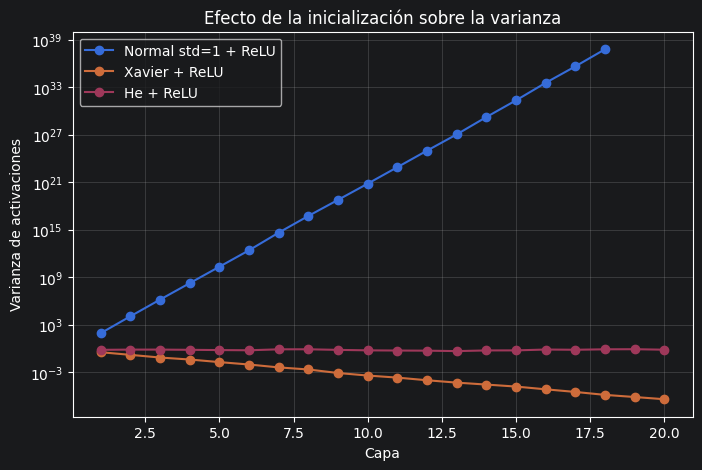

In [13]:
def activation_variance_experiment(init_name, activation_fn, n_layers=20, width=256, n_samples=1024):
    torch.manual_seed(RANDOM_STATE)

    layers = []
    for _ in range(n_layers):
        layer = nn.Linear(width, width)

        if init_name == "normal_std_1":
            nn.init.normal_(layer.weight, mean=0.0, std=1.0)
        elif init_name == "xavier":
            nn.init.xavier_uniform_(layer.weight)
        elif init_name == "he":
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
        else:
            raise ValueError("Inicialización no reconocida")

        nn.init.zeros_(layer.bias)
        layers.append(layer)

    x = torch.randn(n_samples, width)
    variances = []

    with torch.no_grad():
        h = x
        for layer in layers:
            h = activation_fn(layer(h))
            variances.append(h.var().item())

    return variances


experiments = {
    "Normal std=1 + ReLU": activation_variance_experiment("normal_std_1", torch.relu),
    "Xavier + ReLU": activation_variance_experiment("xavier", torch.relu),
    "He + ReLU": activation_variance_experiment("he", torch.relu),
}

plt.figure(figsize=(8, 5))
for label, variances in experiments.items():
    plt.plot(range(1, len(variances) + 1), variances, marker="o", label=label)

plt.xlabel("Capa")
plt.ylabel("Varianza de activaciones")
plt.title("Efecto de la inicialización sobre la varianza")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div style="background:rgba(240,173,78,0.15);border-left:5px solid #f0ad4e;padding:14px;border-radius:6px;color:inherit">

### Pregunta típica

**Xavier no es una técnica de regularización para reducir el sobreajuste.**  
Es una técnica de inicialización pensada para mejorar la estabilidad del entrenamiento.

Técnicas como `dropout`, `weight decay`, `data augmentation` o `early stopping` sí se utilizan para reducir varianza/sobreajuste.

</div>

---

## 7. Normalización y Batch Normalization

Si una característica tiene una escala mucho mayor que otra, los gradientes pueden tener magnitudes muy distintas.  
Esto dificulta la optimización porque el modelo avanza demasiado en unas direcciones y demasiado poco en otras.

Por eso se suelen estandarizar las entradas:

$$
\bar{x} = \frac{x - \mu}{\sigma}
$$

donde:

- $\mu$ es la media;
- $\sigma$ es la desviación típica.

In [14]:
X = np.array([
    [1000, 0.1],
    [1200, 0.2],
    [900,  0.15],
    [1100, 0.12],
], dtype=np.float32)

X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std

print("Original:")
print(X)
print()
print("Estandarizado:")
print(X_scaled)
print()
print("Media:", X_scaled.mean(axis=0))
print("Desviación típica:", X_scaled.std(axis=0))

Original:
[[1.0e+03 1.0e-01]
 [1.2e+03 2.0e-01]
 [9.0e+02 1.5e-01]
 [1.1e+03 1.2e-01]]

Estandarizado:
[[-0.4472136 -1.1283295]
 [ 1.3416408  1.5265638]
 [-1.3416408  0.1991172]
 [ 0.4472136 -0.597351 ]]

Media: [0.0000000e+00 1.0430813e-07]
Desviación típica: [1. 1.]


### 7.1 Batch Normalization

La normalización de entradas ayuda en la primera capa, pero en redes profundas también pueden aparecer activaciones internas con escalas problemáticas.

Batch Normalization normaliza activaciones usando estadísticas del mini-batch:

$$
\hat{h} = \frac{h - \mu_B}{\sigma_B}
$$

y después aprende dos parámetros:

$$
BN(h) = \gamma \hat{h} + \beta
$$

Esto permite que la red pueda recuperar una escala útil si lo necesita.

En PyTorch se usa con capas como:

```python
nn.BatchNorm1d(num_features)
```

In [15]:
class MLPWithBatchNorm(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.model(x)


bn_model = MLPWithBatchNorm()
bn_model

MLPWithBatchNorm(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

<div style="background:rgba(217,83,79,0.13);border-left:5px solid #d9534f;padding:14px;border-radius:6px;color:inherit">

### Importante: `train()` y `eval()`

BatchNorm y Dropout se comportan distinto en entrenamiento e inferencia.

- `model.train()` activa el comportamiento de entrenamiento.
- `model.eval()` activa el comportamiento de inferencia.

Olvidar esto puede cambiar mucho los resultados.

</div>

---

## 8. Regularización en redes profundas

La regularización busca reducir el error de generalización.  
En redes profundas hay varias técnicas habituales:

| Técnica | Idea |
|---|---|
| `weight decay` / L2 | Penaliza pesos grandes |
| `dropout` | Apaga neuronas aleatoriamente durante entrenamiento |
| `early stopping` | Detiene el entrenamiento antes de sobreajustar |
| `data augmentation` | Genera variantes de los datos |
| `batch normalization` | Puede estabilizar y tener efecto regularizador |
| ensembles / snapshots | Combina varios modelos |

### 8.1 Weight decay

En PyTorch, el `weight decay` se configura directamente en el optimizador:

```python
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
```

Añade una penalización que favorece pesos más pequeños.

In [16]:
model = DeepNet(input_dim=2, hidden_dim=32, output_dim=1, n_hidden_layers=3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)

### 8.2 Dropout

Dropout apaga aleatoriamente activaciones durante el entrenamiento.

Si $p$ es la probabilidad de apagar una neurona, entonces una fracción de activaciones se pone a cero.  
Esto obliga a la red a no depender demasiado de neuronas concretas.

En PyTorch:

```python
nn.Dropout(p=0.5)
```

En inferencia, PyTorch desactiva Dropout automáticamente cuando usamos `model.eval()`.

In [17]:
dropout = nn.Dropout(p=0.5)

x_demo = torch.ones(10)

dropout.train()
print("Entrenamiento:")
print(dropout(x_demo))

dropout.eval()
print("\nInferencia:")
print(dropout(x_demo))

Entrenamiento:
tensor([0., 2., 2., 0., 2., 2., 0., 0., 2., 0.])

Inferencia:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


### 8.3 Early stopping

Early stopping consiste en monitorizar la pérdida de validación y detener el entrenamiento cuando deja de mejorar.

Idea:

```text
si val_loss no mejora durante patience épocas:
    parar entrenamiento
```

Esto evita que la red siga ajustándose al ruido del conjunto de entrenamiento.

---

## 9. Entrenamiento completo con PyTorch

Vamos a entrenar una red profunda sobre un problema sintético de clasificación binaria.

Usaremos:

- `TensorDataset`;
- `DataLoader`;
- `nn.Module`;
- `BCEWithLogitsLoss`;
- `Adam`;
- `model.train()` y `model.eval()`.

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### BCEWithLogitsLoss

Para clasificación binaria en PyTorch suele ser mejor usar:

```python
nn.BCEWithLogitsLoss()
```

Esta función combina internamente:

1. una sigmoide;
2. la Binary Cross Entropy.

Por eso la última capa debe devolver un **logit**, no una probabilidad ya pasada por sigmoide.

</div>

In [18]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=RANDOM_STATE)

X = X.astype(np.float32)
y = y.astype(np.float32).reshape(-1, 1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
X_val_tensor = torch.tensor(X_val)
y_val_tensor = torch.tensor(y_val)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print("Train:", X_train_tensor.shape, y_train_tensor.shape)
print("Validation:", X_val_tensor.shape, y_val_tensor.shape)

Train: torch.Size([900, 2]) torch.Size([900, 1])
Validation: torch.Size([300, 2]) torch.Size([300, 1])


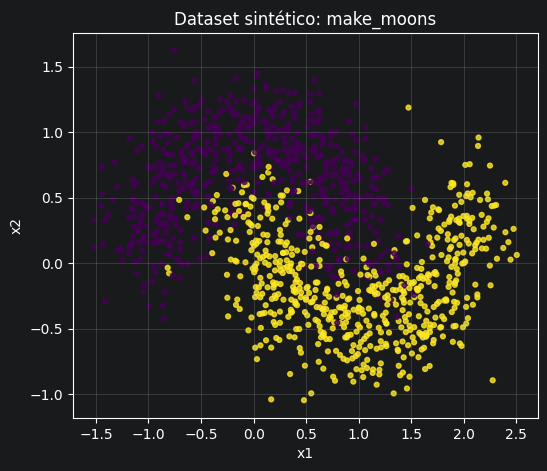

In [19]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=12, alpha=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset sintético: make_moons")
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
class MoonClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=32, output_dim=1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.15),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.15),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.network(x)


model = MoonClassifier().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

model

MoonClassifier(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [21]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_samples = 0
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_probs.append(probs.cpu())
            all_targets.append(y_batch.cpu())

    all_probs = torch.cat(all_probs).numpy()
    all_targets = torch.cat(all_targets).numpy()

    preds = (all_probs >= 0.5).astype(np.float32)
    acc = accuracy_score(all_targets, preds)

    return total_loss / total_samples, acc

In [22]:
n_epochs = 80

history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, n_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch % 20 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

Epoch 001 | train_loss=0.6244 | val_loss=0.6058 | val_acc=0.7967
Epoch 020 | train_loss=0.2771 | val_loss=0.2312 | val_acc=0.9300
Epoch 040 | train_loss=0.2341 | val_loss=0.1805 | val_acc=0.9433
Epoch 060 | train_loss=0.2173 | val_loss=0.1658 | val_acc=0.9467
Epoch 080 | train_loss=0.2213 | val_loss=0.1609 | val_acc=0.9533


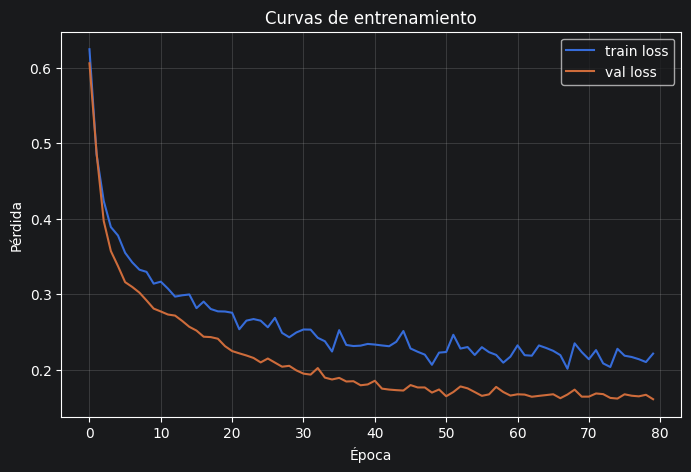

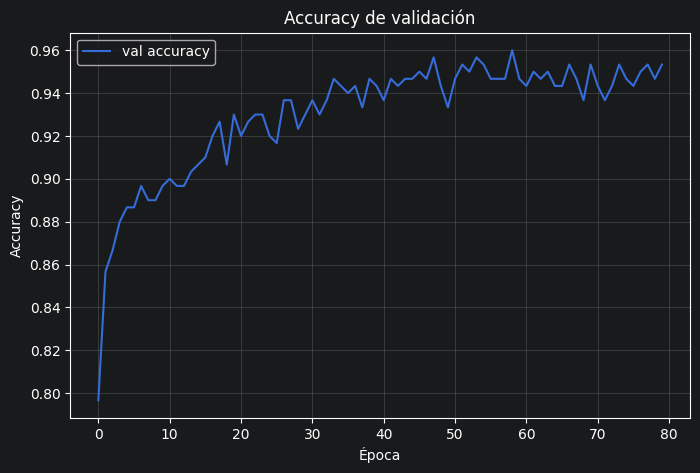

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curvas de entrenamiento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["val_acc"], label="val accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy de validación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
val_loss, val_acc = evaluate(model, val_loader, criterion, device)

model.eval()
with torch.no_grad():
    logits = model(X_val_tensor.to(device))
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

print("Validation loss:", val_loss)
print("Validation accuracy:", val_acc)
print()
print(classification_report(y_val.astype(int), preds))

Validation loss: 0.16092063705126444
Validation accuracy: 0.9533333333333334

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       150
           1       0.95      0.95      0.95       150

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



### 9.1 Visualizar frontera de decisión

En clasificación, una forma muy útil de interpretar una red pequeña es representar su frontera de decisión.

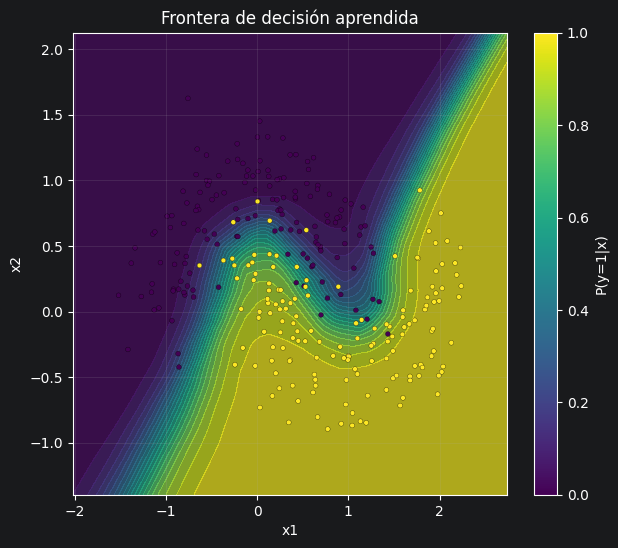

In [25]:
def plot_decision_boundary(model, X, y, device, grid_steps=200):
    model.eval()

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_steps),
        np.linspace(y_min, y_max, grid_steps)
    )

    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_tensor = torch.tensor(grid).to(device)

    with torch.no_grad():
        logits = model(grid_tensor)
        probs = torch.sigmoid(logits).cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, probs, levels=20, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=12, edgecolors="k", linewidths=0.2)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Frontera de decisión aprendida")
    plt.colorbar(label="P(y=1|x)")
    plt.grid(True, alpha=0.2)
    plt.show()


plot_decision_boundary(model, X_val, y_val, device)

---

## 10. Ejercicios tipo examen resueltos

### Ejercicio 1 — Técnica que NO reduce varianza

**Pregunta:** ¿Qué técnica NO es útil para reducir la varianza o el sobreajuste?

Opciones habituales:

- Data augmentation
- Dropout
- Weight decay
- Inicialización de Xavier
- Early stopping

**Respuesta:** Inicialización de Xavier.

**Razón:** Xavier es una técnica de inicialización para estabilizar el flujo de activaciones y gradientes. No está pensada como técnica de regularización. Las demás sí pueden reducir sobreajuste.

### Ejercicio 2 — Activación saturada

Dada:

$$
a(z) = \max(-1, \min(1,z))
$$

Esta función recorta el valor de $z$ al intervalo $[-1,1]$.

Equivalentemente:

$$
a(z)=
\begin{cases}
-1, & z < -1 \\
z, & -1 \le z \le 1 \\
1, & z > 1
\end{cases}
$$

Su derivada es:

$$
a'(z)=
\begin{cases}
0, & z < -1 \\
1, & -1 < z < 1 \\
0, & z > 1
\end{cases}
$$

En $z=-1$ y $z=1$ no es derivable estrictamente, porque hay un cambio brusco de pendiente.

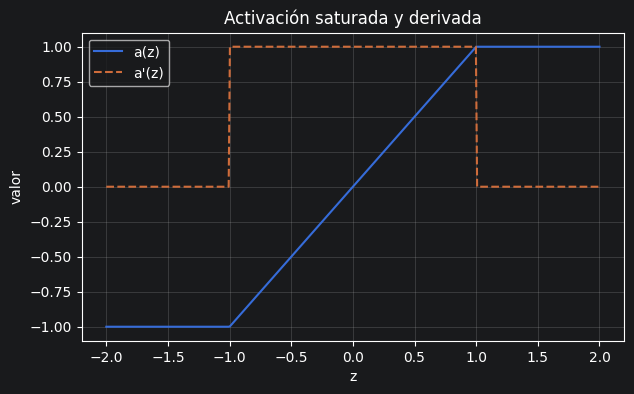

In [26]:
def clipped_activation(z):
    return np.maximum(-1, np.minimum(1, z))

z = np.linspace(-2, 2, 400)
a_z = clipped_activation(z)

derivative = np.where((z > -1) & (z < 1), 1.0, 0.0)

plt.figure(figsize=(7, 4))
plt.plot(z, a_z, label="a(z)")
plt.plot(z, derivative, linestyle="--", label="a'(z)")
plt.xlabel("z")
plt.ylabel("valor")
plt.title("Activación saturada y derivada")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Apartado matricial

Sea:

$$
z = Mx + b
$$

con:

$$
x \in \mathbb{R}^3,\quad M \in \mathbb{R}^{2 \times 3},\quad b \in \mathbb{R}^2
$$

La activación se aplica componente a componente:

$$
a(z)=
\begin{bmatrix}
a(z_1) \\
a(z_2)
\end{bmatrix}
$$

El Jacobiano respecto a $x$ es:

$$
\frac{\partial a(Mx+b)}{\partial x}
=
\frac{\partial a(z)}{\partial z}
\frac{\partial z}{\partial x}
$$

Como:

$$
\frac{\partial z}{\partial x} = M
$$

y:

$$
\frac{\partial a(z)}{\partial z}
=
\begin{bmatrix}
a'(z_1) & 0 \\
0 & a'(z_2)
\end{bmatrix}
$$

entonces:

$$
\boxed{
\frac{\partial a(Mx+b)}{\partial x}
=
\begin{bmatrix}
a'(z_1) & 0 \\
0 & a'(z_2)
\end{bmatrix}
M
}
$$

Si una componente está saturada, su derivada es 0 y la fila correspondiente del Jacobiano se anula.

In [27]:
M = torch.tensor([[1.0, -2.0, 0.5],
                  [0.3,  0.2, 1.0]])

b = torch.tensor([0.1, -0.4])
x = torch.tensor([0.8, -0.2, 0.5])

z = M @ x + b
a = torch.clamp(z, min=-1.0, max=1.0)

a_prime = ((z > -1.0) & (z < 1.0)).float()
J = torch.diag(a_prime) @ M

print("z =", z)
print("a(z) =", a)
print("a'(z) =", a_prime)
print("Jacobian da/dx:")
print(J)

z = tensor([1.5500, 0.3000])
a(z) = tensor([1.0000, 0.3000])
a'(z) = tensor([0., 1.])
Jacobian da/dx:
tensor([[0.0000, 0.0000, 0.0000],
        [0.3000, 0.2000, 1.0000]])


### Ejercicio 3 — Número de parámetros en red profunda

Tenemos:

- $D_i = 1$ entrada;
- $D_o = 2$ salidas;
- $K = 8$ capas ocultas;
- $D = 10$ unidades ocultas por capa.

La fórmula es:

$$
P =
D(D_i + 1)
+
(K-1)D(D+1)
+
D_o(D+1)
$$

Sustituyendo:

$$
P =
10(1+1)
+
(8-1)10(10+1)
+
2(10+1)
$$

$$
P = 20 + 770 + 22 = 812
$$

Por tanto, la red tiene:

$$
\boxed{812 \text{ parámetros}}
$$

La **anchura** es:

$$
\boxed{D = 10}
$$

La **profundidad**, contando capas ocultas según el enunciado, es:

$$
\boxed{K = 8}
$$

Si se cuenta también la capa de salida como capa parametrizada, habría 9 capas lineales.

In [28]:
Di, Do, K, D = 1, 2, 8, 10

params = count_parameters_formula(Di, Do, K, D)

for key, value in params.items():
    print(f"{key}: {value}")

first_hidden: 20
hidden_to_hidden: 770
output_layer: 22
total: 812


#### Código PyTorch del modelo pedido

El siguiente código crea exactamente la red del ejercicio y hace inferencia sobre un tensor `x0`.

In [29]:
class ExamDeepNetwork(nn.Module):
    def __init__(self, Di=1, Do=2, K=8, D=10):
        super().__init__()

        layers = []

        layers.append(nn.Linear(Di, D))
        layers.append(nn.ReLU())

        for _ in range(K - 1):
            layers.append(nn.Linear(D, D))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(D, Do))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


exam_model = ExamDeepNetwork(Di=1, Do=2, K=8, D=10)

x0 = torch.tensor([[0.25]], dtype=torch.float32)
y0 = exam_model(x0)

print(exam_model)
print("x0.shape:", x0.shape)
print("y0.shape:", y0.shape)
print("y0:", y0)
print("Número de parámetros:", count_parameters_torch(exam_model))

ExamDeepNetwork(
  (model): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=10, bias=True)
    (5): ReLU()
    (6): Linear(in_features=10, out_features=10, bias=True)
    (7): ReLU()
    (8): Linear(in_features=10, out_features=10, bias=True)
    (9): ReLU()
    (10): Linear(in_features=10, out_features=10, bias=True)
    (11): ReLU()
    (12): Linear(in_features=10, out_features=10, bias=True)
    (13): ReLU()
    (14): Linear(in_features=10, out_features=10, bias=True)
    (15): ReLU()
    (16): Linear(in_features=10, out_features=2, bias=True)
  )
)
x0.shape: torch.Size([1, 1])
y0.shape: torch.Size([1, 2])
y0: tensor([[0.1882, 0.1340]], grad_fn=<AddmmBackward0>)
Número de parámetros: 812


---

## 11. Resumen final

| Concepto | Idea clave |
|---|---|
| Red profunda | Red con varias capas ocultas |
| Profundidad | Número de capas ocultas, según la notación del tema |
| Anchura | Número de unidades ocultas por capa |
| Composición | Cada capa transforma la representación anterior |
| ReLU | Genera funciones lineales a trozos |
| Xavier | Inicialización pensada para estabilizar varianzas |
| He | Inicialización habitual para ReLU |
| BatchNorm | Normaliza activaciones internas y aprende escala/desplazamiento |
| Dropout | Apaga activaciones aleatoriamente durante entrenamiento |
| Weight decay | Penaliza pesos grandes |
| Early stopping | Detiene antes de sobreajustar |
| Autograd | Motor de derivación automática de PyTorch |
| DataLoader | Carga datos por mini-batches |
| `model.train()` | Modo entrenamiento |
| `model.eval()` | Modo inferencia |

## Checklist de examen

<div style="background:rgba(92,184,92,0.13);border-left:5px solid #3c763d;padding:14px;border-radius:6px;color:inherit">

Antes del examen deberías saber hacer sin mirar:

1. Calcular el número de parámetros de una red completamente conectada.
2. Distinguir anchura y profundidad.
3. Explicar por qué una activación debe ser no lineal.
4. Escribir una red con `torch.nn.Sequential`.
5. Usar `BCEWithLogitsLoss` correctamente.
6. Explicar qué hace `optimizer.zero_grad()`, `loss.backward()` y `optimizer.step()`.
7. Saber por qué Xavier no es regularización.
8. Explicar Dropout, BatchNorm, Weight Decay y Early Stopping.
9. Derivar una activación por tramos.
10. Escribir el Jacobiano de $a(Mx+b)$ usando regla de la cadena.

</div>

---

## Cierre

Este notebook conecta la teoría de redes profundas con la implementación real en PyTorch.  
La parte más importante no es memorizar código, sino entender el flujo completo:

```text
datos → tensores → modelo → forward → loss → backward → optimizer.step()
```

Ese patrón se repite en casi todos los proyectos de Deep Learning con PyTorch.